# Shiv Nadar University Chennai

| Field | Detail |
|---|---|
| **Degree & Branch** | B.Tech Artificial Intelligence & Data Science, Semester V |
| **Subject** | CS3807 – Deep Learning Laboratory (AY 2026–27) |
| **Name** | R S Kirithic |
| **Section** | AIDS B |
| **Register Number** | 24011101082 |

## Experiment 4
### Comparative Study of Deep Convolutional Neural Network Architectures Using Transfer Learning


## Objective

- Study the evolution of deep CNN architectures.
- Compare LeNet-5, AlexNet, VGG16, GoogleNet and ResNet.
- Understand transfer learning.
- Fine tune a pretrained CNN model.
- Compare classification performance before and after fine-tuning.

**Base model used for this notebook: `MobileNetV2`** (one of the four options listed in the manual — VGG16, ResNet50, MobileNetV2, EfficientNetB0). To switch, just change `BASE_MODEL_NAME` in the Task 2 cell below.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import time
import os

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# ---- Plot styling: Times New Roman, size 13, exported as 600 DPI EPS ----
# On Colab, Times New Roman is usually not installed by default. If the
# plots render in a fallback font, uncomment the two lines below once and
# re-run this cell:
# !apt-get install -y msttcorefonts -qq > /dev/null
# !rm -rf ~/.cache/matplotlib

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 13

FIGURE_DIR = 'figures'
os.makedirs(FIGURE_DIR, exist_ok=True)

def save_fig(fig, name):
    """Saves a figure as a 600 DPI EPS file in the figures/ directory."""
    fig.savefig(f'{FIGURE_DIR}/{name}.eps', format='eps', dpi=600, bbox_inches='tight')

class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

TensorFlow version: 2.20.0
Num GPUs Available: 1


## Task 1: Dataset Preparation

1. Load the CIFAR-10 dataset using TensorFlow/Keras.
2. Normalize the pixel values to the range [0, 1].
3. Display ten sample images.
4. Print the dimensions of the training and testing datasets.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3047s 18us/step


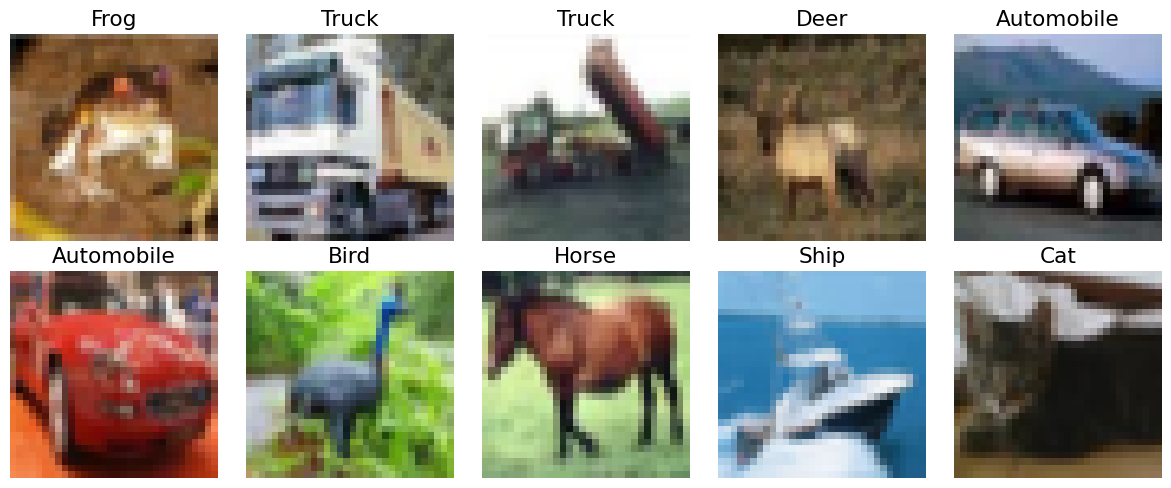

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[y_train[i][0]])
    ax.axis('off')
plt.tight_layout()
save_fig(fig, '01_sample_cifar10_images')
plt.show()

In [4]:
print(f"Training data shape  : {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing data shape   : {x_test.shape}")
print(f"Testing labels shape : {y_test.shape}")

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

Training data shape  : (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape   : (10000, 32, 32, 3)
Testing labels shape : (10000, 1)


## Task 2: Transfer Learning

1. Load pretrained ImageNet weights.
2. Remove the original classification layer.
3. Freeze the convolutional base.
4. Add a Global Average Pooling layer.
5. Add a Dense layer with ReLU activation.
6. Add the output layer with Softmax activation.

In [5]:
BASE_MODEL_NAME = 'MobileNetV2'  # Options: 'VGG16', 'ResNet50', 'MobileNetV2', 'EfficientNetB0'

def get_base_model(name, input_shape=(32, 32, 3)):
    if name == 'VGG16':
        return keras.applications.VGG16(input_shape=input_shape, include_top=False, weights='imagenet')
    elif name == 'ResNet50':
        return keras.applications.ResNet50(input_shape=input_shape, include_top=False, weights='imagenet')
    elif name == 'MobileNetV2':
        return keras.applications.MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    elif name == 'EfficientNetB0':
        return keras.applications.EfficientNetB0(input_shape=input_shape, include_top=False, weights='imagenet')
    else:
        raise ValueError(f"Unknown base model: {name}")


def build_model(base_name='MobileNetV2', dense_units=128, frozen='all'):
    """
    Task 2 / Task 4 model builder.
    frozen='all'     -> convolutional base fully frozen (Task 2 / Task 3).
    frozen='partial' -> last convolutional block unfrozen (Task 4 fine-tuning).
    """
    base_model = get_base_model(base_name)

    if frozen == 'all':
        base_model.trainable = False
    elif frozen == 'partial':
        base_model.trainable = True
        # last conv block; clamped at 0 so shallow bases (e.g. VGG16) don't
        # get a negative slice index
        fine_tune_at = max(0, len(base_model.layers) - 20)
        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False
    else:
        raise ValueError("frozen must be 'all' or 'partial'")

    inputs = keras.Input(shape=(32, 32, 3))
    # training=False keeps BatchNorm layers in inference mode, which is
    # recommended even when part of the base model is set trainable=True.
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

In [6]:
model, base_model = build_model(base_name=BASE_MODEL_NAME, dense_units=128, frozen='all')
model.summary()

/tmp/ipykernel_570/2645102223.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  return keras.applications.MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Task 3: Model Training

Optimizer: Adam, Learning Rate: 0.001, Batch Size: 32, Epochs: 15 (within the 10–20 range), Loss: Categorical Cross-Entropy, Metric: Accuracy.

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history_initial = model.fit(
    x_train, y_train_cat,
    validation_data=(x_test, y_test_cat),
    batch_size=32,
    epochs=15,
    verbose=1
)
training_time_initial = time.time() - start_time

test_loss_before, test_acc_before = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test Accuracy before fine-tuning: {test_acc_before:.4f}")
print(f"Training time (initial): {training_time_initial:.2f} seconds")

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 18ms/step - accuracy: 0.3005 - loss: 1.9289 - val_accuracy: 0.3291 - val_loss: 1.8583
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.3365 - loss: 1.8252 - val_accuracy: 0.3432 - val_loss: 1.8256
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.3498 - loss: 1.7870 - val_accuracy: 0.3486 - val_loss: 1.8100
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.3603 - loss: 1.7598 - val_accuracy: 0.3516 - val_loss: 1.8019
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3683 - loss: 1.7385 - val_accuracy: 0.3537 - val_loss: 1.7975
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3745 - loss: 1.7209 - val_accuracy: 0.3540 - val_loss: 1.7954
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3808 - loss: 1.7056 - val_accuracy: 0.3550 - val_loss: 1.7959
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3852 - loss: 

## Task 4: Fine Tuning

1. Unfreeze the last convolution block.
2. Train for another 5–10 epochs.
3. Compare the classification accuracy before and after fine tuning.

In [8]:
# Unfreeze the last convolutional block of the base model
base_model.trainable = True
fine_tune_at = max(0, len(base_model.layers) - 20)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history_finetune = model.fit(
    x_train, y_train_cat,
    validation_data=(x_test, y_test_cat),
    batch_size=32,
    epochs=8,
    verbose=1
)
training_time_finetune = time.time() - start_time

test_loss_after, test_acc_after = model.evaluate(x_test, y_test_cat, verbose=0)

print(f"Test Accuracy before fine-tuning: {test_acc_before:.4f}")
print(f"Test Accuracy after fine-tuning : {test_acc_after:.4f}")
print(f"Training time (fine-tuning): {training_time_finetune:.2f} seconds")

Epoch 1/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - accuracy: 0.3996 - loss: 2.4666 - val_accuracy: 0.3833 - val_loss: 1.7730
Epoch 2/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5204 - loss: 1.3816 - val_accuracy: 0.4441 - val_loss: 1.6505
Epoch 3/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5623 - loss: 1.2757 - val_accuracy: 0.5009 - val_loss: 1.5546
Epoch 4/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5836 - loss: 1.2202 - val_accuracy: 0.5104 - val_loss: 1.5544
Epoch 5/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5999 - loss: 1.1716 - val_accuracy: 0.4644 - val_loss: 1.9578
Epoch 6/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6159 - loss: 1.1131 - val_accuracy: 0.5156 - val_loss: 1.5842
Epoch 7/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6332 - loss: 1.0670 - val_accuracy: 0.5335 - val_loss: 1.5483
Epoch 8/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6549 - loss: 0.9988 -

### Mandatory Plots — Training/Validation Accuracy and Loss

Curves combine the Task 3 (frozen base) and Task 4 (fine-tuning) training phases, with a dashed line marking where fine-tuning starts.

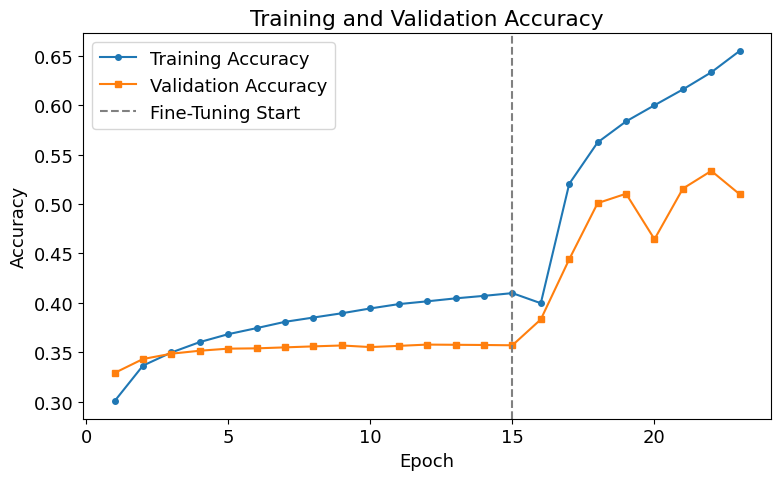

In [9]:
acc = history_initial.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history_initial.history['val_accuracy'] + history_finetune.history['val_accuracy']
epochs_range = range(1, len(acc) + 1)
finetune_start = len(history_initial.history['accuracy'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs_range, acc, label='Training Accuracy', marker='o', markersize=4)
ax.plot(epochs_range, val_acc, label='Validation Accuracy', marker='s', markersize=4)
ax.axvline(x=finetune_start, linestyle='--', color='gray', label='Fine-Tuning Start')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Training and Validation Accuracy')
ax.legend()
plt.tight_layout()
save_fig(fig, '02_training_validation_accuracy')
plt.show()

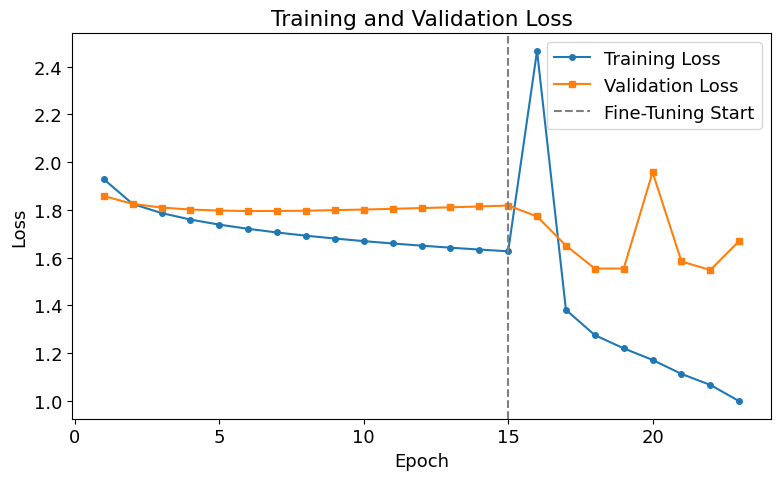

In [10]:
loss = history_initial.history['loss'] + history_finetune.history['loss']
val_loss = history_initial.history['val_loss'] + history_finetune.history['val_loss']

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs_range, loss, label='Training Loss', marker='o', markersize=4)
ax.plot(epochs_range, val_loss, label='Validation Loss', marker='s', markersize=4)
ax.axvline(x=finetune_start, linestyle='--', color='gray', label='Fine-Tuning Start')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss')
ax.legend()
plt.tight_layout()
save_fig(fig, '03_training_validation_loss')
plt.show()

## Task 5: Model Evaluation

Accuracy, Precision, Recall, F1-score, Confusion Matrix, Classification Report.

In [11]:
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print()
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step
Accuracy  : 0.5098
Precision : 0.5462
Recall    : 0.5098
F1-score  : 0.5003

Classification Report:
              precision    recall  f1-score   support

    Airplane       0.69      0.36      0.48      1000
  Automobile       0.38      0.89      0.53      1000
        Bird       0.54      0.41      0.46      1000
         Cat       0.47      0.29      0.36      1000
        Deer       0.60      0.30      0.40      1000
         Dog       0.54      0.44      0.49      1000
        Frog       0.56      0.56      0.56      1000
       Horse       0.56      0.65      0.60      1000
        Ship       0.46      0.69      0.55      1000
       Truck       0.67      0.50      0.57      1000

    accuracy                           0.51     10000
   macro avg       0.55      0.51      0.50     10000
weighted avg       0.55      0.51      0.50     10000



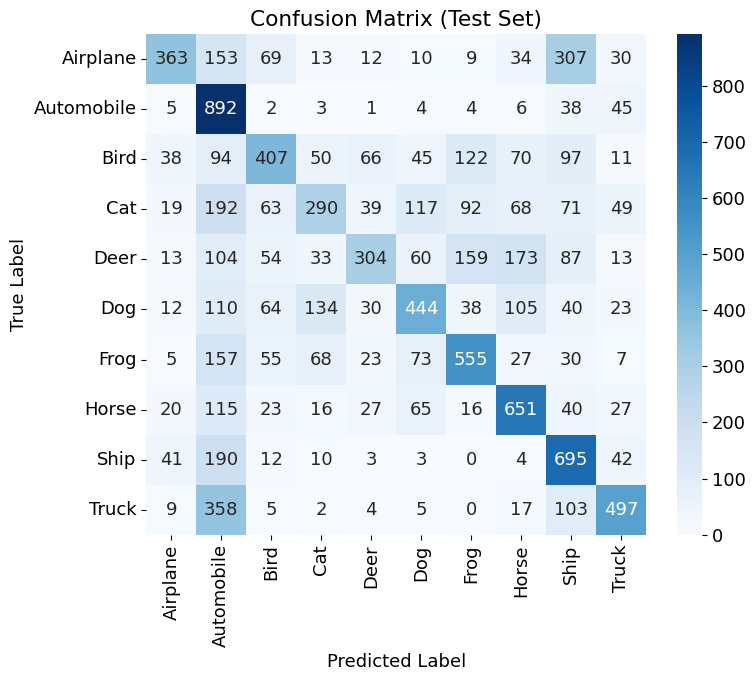

In [12]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix (Test Set)')
plt.tight_layout()
save_fig(fig, '04_confusion_matrix')
plt.show()

### Misclassified Images (Optional)

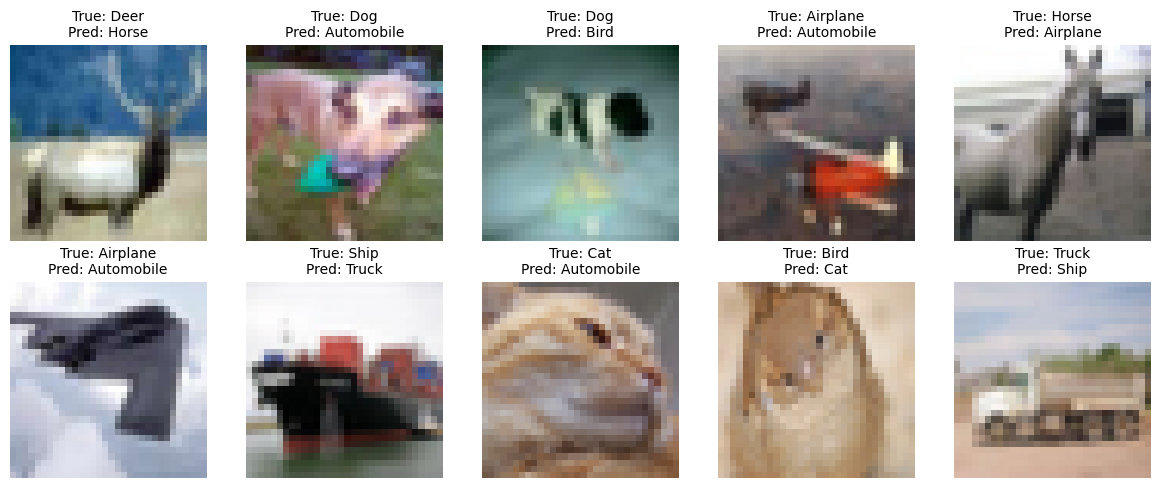

In [13]:
misclassified_idx = np.where(y_pred != y_true)[0]
n_show = min(10, len(misclassified_idx))
sample_idx = np.random.choice(misclassified_idx, size=n_show, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    if i < n_show:
        idx = sample_idx[i]
        ax.imshow(x_test[idx])
        ax.set_title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=10)
    ax.axis('off')
plt.tight_layout()
save_fig(fig, '05_misclassified_images')
plt.show()

### Performance Summary

In [14]:
total_training_time = training_time_initial + training_time_finetune

performance_summary = pd.DataFrame({
    'Metric': ['Training Accuracy', 'Testing Accuracy', 'Precision', 'Recall',
               'F1-score', 'Training Time (s)', 'Total Parameters'],
    'Value': [
        history_finetune.history['accuracy'][-1],
        accuracy,
        precision,
        recall,
        f1,
        round(total_training_time, 2),
        model.count_params()
    ]
})
performance_summary

,Metric,Value
0,Training Accuracy,6.549200e-01
1,Testing Accuracy,5.098000e-01
2,Precision,5.461972e-01
3,Recall,5.098000e-01
4,F1-score,5.002530e-01
5,Training Time (s),3.451000e+02
6,Total Parameters,2.423242e+06


## Hyperparameter Study

Each hyperparameter is varied one at a time while the rest are held at the baseline setting (Learning Rate 0.001, Batch Size 32, Epochs 10, Optimizer Adam, Dense Units 128, Frozen Layers All). Each run trains a fresh model.

In [15]:
def train_and_evaluate(label, dense_units=128, frozen='all', optimizer_name='adam',
                        learning_rate=0.001, batch_size=32, epochs=10, verbose=0):
    hp_model, _ = build_model(base_name=BASE_MODEL_NAME, dense_units=dense_units, frozen=frozen)

    if optimizer_name == 'adam':
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate)

    hp_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    start_time = time.time()
    hp_model.fit(
        x_train, y_train_cat,
        validation_data=(x_test, y_test_cat),
        batch_size=batch_size,
        epochs=epochs,
        verbose=verbose
    )
    hp_training_time = time.time() - start_time

    hp_test_loss, hp_test_acc = hp_model.evaluate(x_test, y_test_cat, verbose=0)

    return {
        'Setting': label,
        'Test Accuracy': round(hp_test_acc, 4),
        'Test Loss': round(hp_test_loss, 4),
        'Training Time (s)': round(hp_training_time, 2),
        'Total Parameters': hp_model.count_params()
    }

In [16]:
hyperparam_results = []

hyperparam_results.append(train_and_evaluate(
    'Baseline (lr=0.001, batch=32, epochs=10, Adam, dense=128, frozen=all)'))

# Learning Rate
hyperparam_results.append(train_and_evaluate('Learning Rate = 0.0001', learning_rate=0.0001))

# Batch Size
hyperparam_results.append(train_and_evaluate('Batch Size = 16', batch_size=16))
hyperparam_results.append(train_and_evaluate('Batch Size = 64', batch_size=64))

# Epochs
hyperparam_results.append(train_and_evaluate('Epochs = 20', epochs=20))

# Optimizer
hyperparam_results.append(train_and_evaluate('Optimizer = SGD', optimizer_name='sgd'))

# Dense Units
hyperparam_results.append(train_and_evaluate('Dense Units = 256', dense_units=256))

# Frozen Layers
hyperparam_results.append(train_and_evaluate('Frozen Layers = Partial', frozen='partial'))

hyperparam_df = pd.DataFrame(hyperparam_results)
hyperparam_df

/tmp/ipykernel_570/2645102223.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  return keras.applications.MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')


,Setting,Test Accuracy,Test Loss,Training Time (s),Total Parameters
0,"Baseline (lr=0.001, batch=32, epochs=10, Adam,...",0.3602,1.7983,145.37,2423242
1,Learning Rate = 0.0001,0.3271,1.8616,128.35,2423242
2,Batch Size = 16,0.3548,1.8116,221.54,2423242
3,Batch Size = 64,0.3570,1.7949,85.06,2423242
4,Epochs = 20,0.3579,1.8365,267.75,2423242
5,Optimizer = SGD,0.2596,2.0710,127.48,2423242
6,Dense Units = 256,0.3529,1.8086,141.49,2588490
7,Frozen Layers = Partial,0.5697,2.1749,158.96,2423242


## Additional Exercises

### Exercises 1 & 2: Transfer Learning using VGG16 and ResNet50

Same Task 2 → Task 3 → Task 4 pipeline (frozen training, then fine-tuning), repeated with a different pretrained base each time. VGG16 and ResNet50 are both heavier than MobileNetV2, so these two cells will take longer to run.

In [17]:
def run_transfer_learning_pipeline(base_name, dense_units=128, initial_epochs=15,
                                    finetune_epochs=8, batch_size=32,
                                    learning_rate=0.001, verbose=1):
    """
    Runs the full Task 2 -> Task 3 -> Task 4 pipeline (frozen training, then
    fine-tuning) for the given pretrained base model and returns a results
    dictionary in the same shape as the Section 18.2 comparison table.
    """
    ex_model, ex_base = build_model(base_name=base_name, dense_units=dense_units, frozen='all')

    ex_model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                      loss='categorical_crossentropy', metrics=['accuracy'])

    start_time = time.time()
    ex_model.fit(x_train, y_train_cat, validation_data=(x_test, y_test_cat),
                 batch_size=batch_size, epochs=initial_epochs, verbose=verbose)

    # Fine-tuning: unfreeze the last convolutional block
    ex_base.trainable = True
    fine_tune_at = max(0, len(ex_base.layers) - 20)
    for layer in ex_base.layers[:fine_tune_at]:
        layer.trainable = False

    ex_model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                      loss='categorical_crossentropy', metrics=['accuracy'])

    ex_model.fit(x_train, y_train_cat, validation_data=(x_test, y_test_cat),
                 batch_size=batch_size, epochs=finetune_epochs, verbose=verbose)
    training_time = time.time() - start_time

    ex_pred = np.argmax(ex_model.predict(x_test, verbose=0), axis=1)
    ex_true = y_test.flatten()

    return {
        'Model': base_name,
        'Parameters': ex_model.count_params(),
        'Accuracy (%)': round(accuracy_score(ex_true, ex_pred) * 100, 2),
        'Precision': round(precision_score(ex_true, ex_pred, average='weighted'), 4),
        'Recall': round(recall_score(ex_true, ex_pred, average='weighted'), 4),
        'F1-score': round(f1_score(ex_true, ex_pred, average='weighted'), 4),
        'Training Time (s)': round(training_time, 2)
    }

In [18]:
vgg16_results = run_transfer_learning_pipeline('VGG16')
vgg16_results

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.5237 - loss: 1.3684 - val_accuracy: 0.5614 - val_loss: 1.2572
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5848 - loss: 1.1888 - val_accuracy: 0.5829 - val_loss: 1.2045
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6041 - loss: 1.1334 - val_accuracy: 0.5894 - val_loss: 1.1821
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6185 - loss: 1.0928 - val_accuracy: 0.5957 - val_loss: 1.1636
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6289 - loss: 1.0597 - val_accuracy: 0.6040 - val_loss: 1.1543
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6394 - loss: 1.0307 - val_accuracy: 0.6066 - val_loss: 1.1468
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6494 - loss: 1.0051 - val_accuracy: 0.6084 - val_loss: 1.1410
Epoch 8/15
1563/1563 ━━━━━━━━━━

{'Model': 'VGG16',
 'Parameters': 14781642,
 'Accuracy (%)': 77.46,
 'Precision': 0.7811,
 'Recall': 0.7746,
 'F1-score': 0.7755,
 'Training Time (s)': 853.24}

In [19]:
resnet50_results = run_transfer_learning_pipeline('ResNet50')
resnet50_results

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - accuracy: 0.2526 - loss: 2.0477 - val_accuracy: 0.3130 - val_loss: 1.8966
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.3186 - loss: 1.8780 - val_accuracy: 0.3451 - val_loss: 1.8178
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.3420 - loss: 1.8203 - val_accuracy: 0.3623 - val_loss: 1.7755
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.3565 - loss: 1.7870 - val_accuracy: 0.3762 - val_loss: 1.7440
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.3644 - loss: 1.7638 - val_accuracy: 0.3820 - val_loss: 1.7276
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.3721 - loss: 1.7421 - val_accuracy: 0.3866 - val_loss: 1.7084
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.3789 - loss: 1.7263 - val_accuracy: 0.3928 - val_loss: 1.6940
Epoch 8/15
1563/1563 ━━━━━━━━━━

{'Model': 'ResNet50',
 'Parameters': 23851274,
 'Accuracy (%)': 23.55,
 'Precision': 0.4161,
 'Recall': 0.2355,
 'F1-score': 0.172,
 'Training Time (s)': 432.65}

### Exercise 6: Compare AlexNet (from scratch) vs ResNet (transfer learning)

LeNet-5 is skipped here per your instructions, so this compares AlexNet against ResNet only.

AlexNet is adapted for CIFAR-10's 32×32 resolution: the original architecture's kernel sizes and strides assume 224×224 ImageNet input, which would collapse a 32×32 image almost immediately, so they're scaled down here while keeping the same 5-conv + 3-FC structure. The "ResNet" side of the comparison reuses the `resnet50_results` computed in Exercise 2 above.

In [20]:
def build_alexnet(input_shape=(32, 32, 3), num_classes=10):
    """
    AlexNet-style CNN adapted for 32x32 CIFAR-10 images (kernel sizes and
    strides scaled down from the original 224x224 AlexNet, same 5-conv +
    3-FC structure). Trained from scratch, no pretrained weights.
    """
    alexnet = keras.Sequential([
        layers.Conv2D(64, (3, 3), padding='same', activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(192, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(384, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return alexnet

In [21]:
alexnet_model = build_alexnet()
alexnet_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                       loss='categorical_crossentropy', metrics=['accuracy'])

start_time = time.time()
alexnet_history = alexnet_model.fit(
    x_train, y_train_cat,
    validation_data=(x_test, y_test_cat),
    batch_size=32,
    epochs=20,
    verbose=1
)
alexnet_training_time = time.time() - start_time

alexnet_pred = np.argmax(alexnet_model.predict(x_test, verbose=0), axis=1)
alexnet_true = y_test.flatten()

alexnet_results = {
    'Model': 'AlexNet (from scratch)',
    'Parameters': alexnet_model.count_params(),
    'Accuracy (%)': round(accuracy_score(alexnet_true, alexnet_pred) * 100, 2),
    'Precision': round(precision_score(alexnet_true, alexnet_pred, average='weighted'), 4),
    'Recall': round(recall_score(alexnet_true, alexnet_pred, average='weighted'), 4),
    'F1-score': round(f1_score(alexnet_true, alexnet_pred, average='weighted'), 4),
    'Training Time (s)': round(alexnet_training_time, 2)
}
alexnet_results

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - accuracy: 0.0988 - loss: 2.3036 - val_accuracy: 0.1000 - val_loss: 2.3029
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.0993 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3028
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.0986 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.0986 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.0978 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.0984 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.0979 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.0979 -

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'Model': 'AlexNet (from scratch)',
 'Parameters': 7506762,
 'Accuracy (%)': 10.0,
 'Precision': 0.01,
 'Recall': 0.1,
 'F1-score': 0.0182,
 'Training Time (s)': 385.69}

In [22]:
comparison_df = pd.DataFrame([alexnet_results, resnet50_results])
comparison_df

,Model,Parameters,Accuracy (%),Precision,Recall,F1-score,Training Time (s)
0,AlexNet (from scratch),7506762,10.00,0.0100,0.1000,0.0182,385.69
1,ResNet50,23851274,23.55,0.4161,0.2355,0.1720,432.65


## Saved Figures

In [23]:
print("Saved figures (600 DPI EPS, Times New Roman 13pt):")
for f in sorted(os.listdir(FIGURE_DIR)):
    print(f)

Saved figures (600 DPI EPS, Times New Roman 13pt):
01_sample_cifar10_images.eps
02_training_validation_accuracy.eps
03_training_validation_loss.eps
04_confusion_matrix.eps
05_misclassified_images.eps
